# NOTEBOOK 3: VISUALIZATIONS

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

In [2]:
df = pd.read_csv('../data/superstore_clean.csv')
sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 120


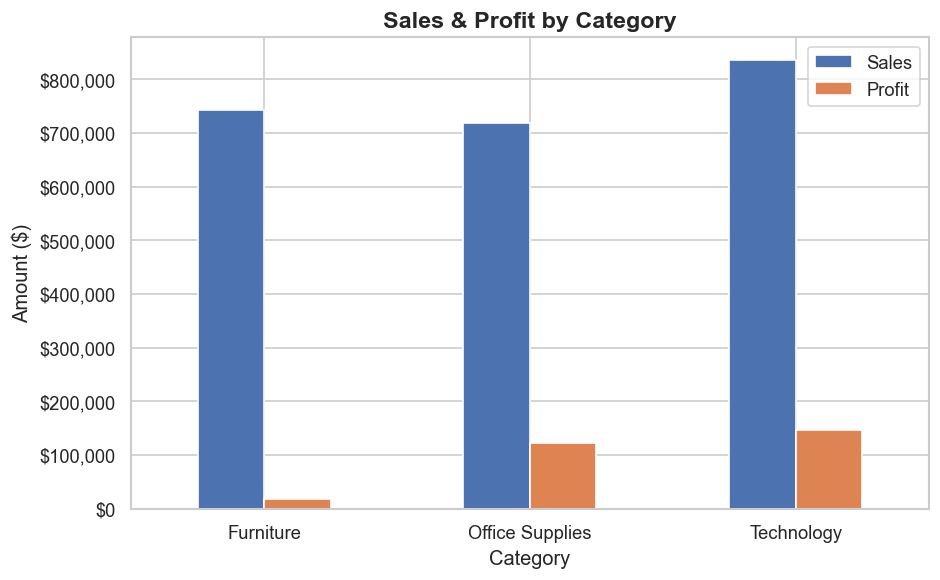

In [3]:
# --- Chart 1: Sales & Profit by Category ---
fig, ax = plt.subplots(figsize=(8, 5))
category_data = df.groupby('Category')[['Sales', 'Profit']].sum()
category_data.plot(kind='bar', ax=ax, color=['#4C72B0', '#DD8452'])
ax.set_title('Sales & Profit by Category', fontsize=14, fontweight='bold')
ax.set_xlabel('Category')
ax.set_ylabel('Amount ($)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('../exports/01_category_sales.png')
plt.show()


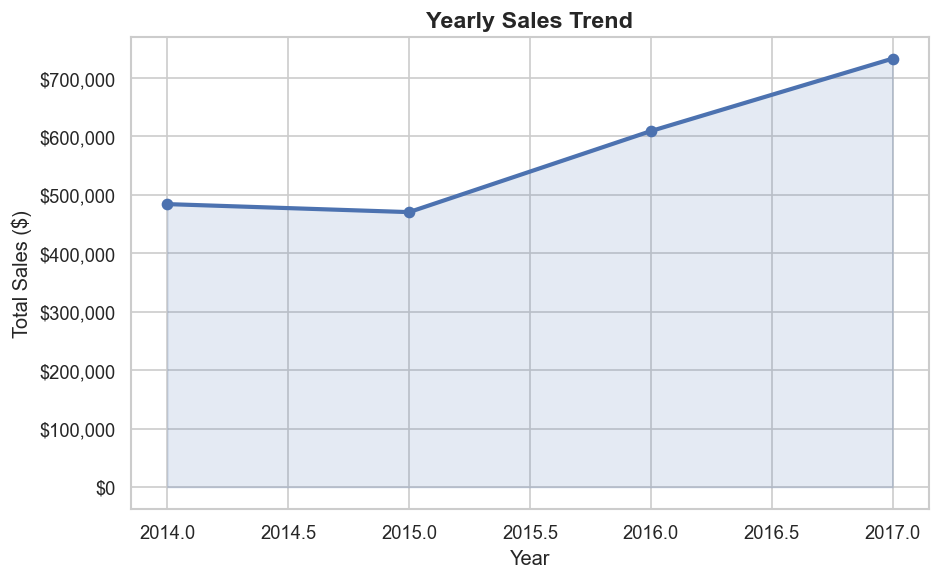

In [4]:
# --- Chart 2: Yearly Sales Trend ---
fig, ax = plt.subplots(figsize=(8, 5))
yearly = df.groupby('Order_Year')['Sales'].sum()
ax.plot(yearly.index, yearly.values, marker='o', linewidth=2.5, color='#4C72B0')
ax.fill_between(yearly.index, yearly.values, alpha=0.15, color='#4C72B0')
ax.set_title('Yearly Sales Trend', fontsize=14, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Total Sales ($)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.tight_layout()
plt.savefig('../exports/02_yearly_trend.png')
plt.show()

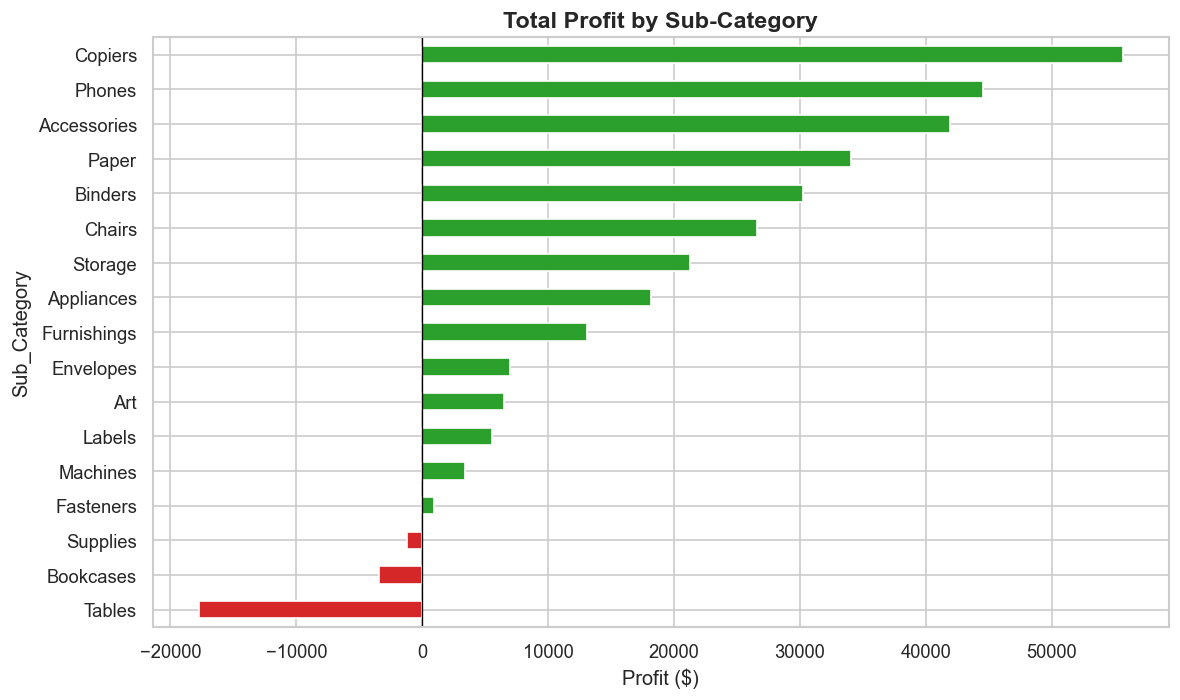

In [5]:
# --- Chart 3: Profit Margin by Sub-Category ---
fig, ax = plt.subplots(figsize=(10, 6))
subcat = df.groupby('Sub_Category')['Profit'].sum().sort_values()
colors = ['#d62728' if x < 0 else '#2ca02c' for x in subcat.values]
subcat.plot(kind='barh', ax=ax, color=colors)
ax.set_title('Total Profit by Sub-Category', fontsize=14, fontweight='bold')
ax.set_xlabel('Profit ($)')
ax.axvline(x=0, color='black', linewidth=0.8)
plt.tight_layout()
plt.savefig('../exports/03_subcat_profit.png')
plt.show()

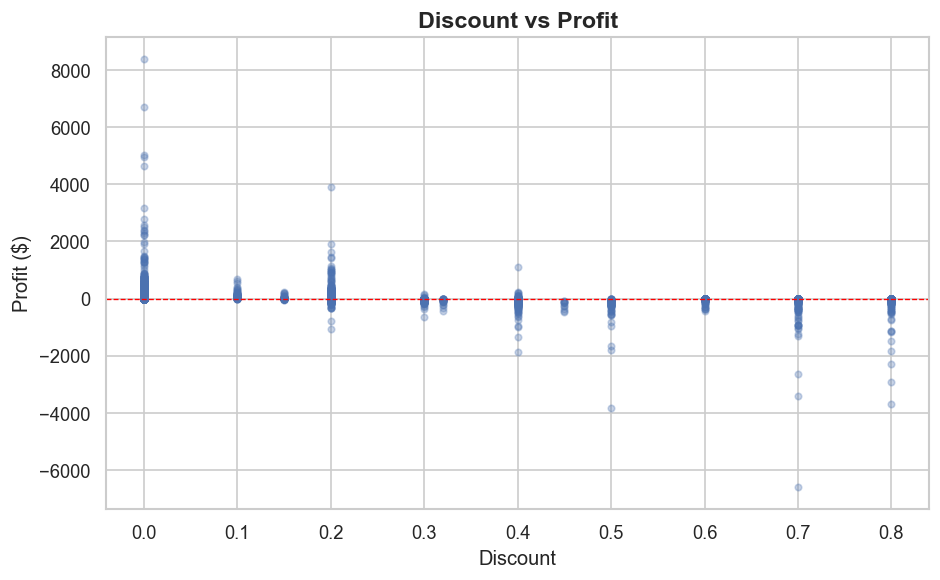

In [6]:
# --- Chart 4: Discount vs Profit Scatter ---
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(df['Discount'], df['Profit'], alpha=0.3, color='#4C72B0', s=15)
ax.set_title('Discount vs Profit', fontsize=14, fontweight='bold')
ax.set_xlabel('Discount')
ax.set_ylabel('Profit ($)')
ax.axhline(y=0, color='red', linestyle='--', linewidth=0.8)
plt.tight_layout()
plt.savefig('../exports/04_discount_profit.png')
plt.show()

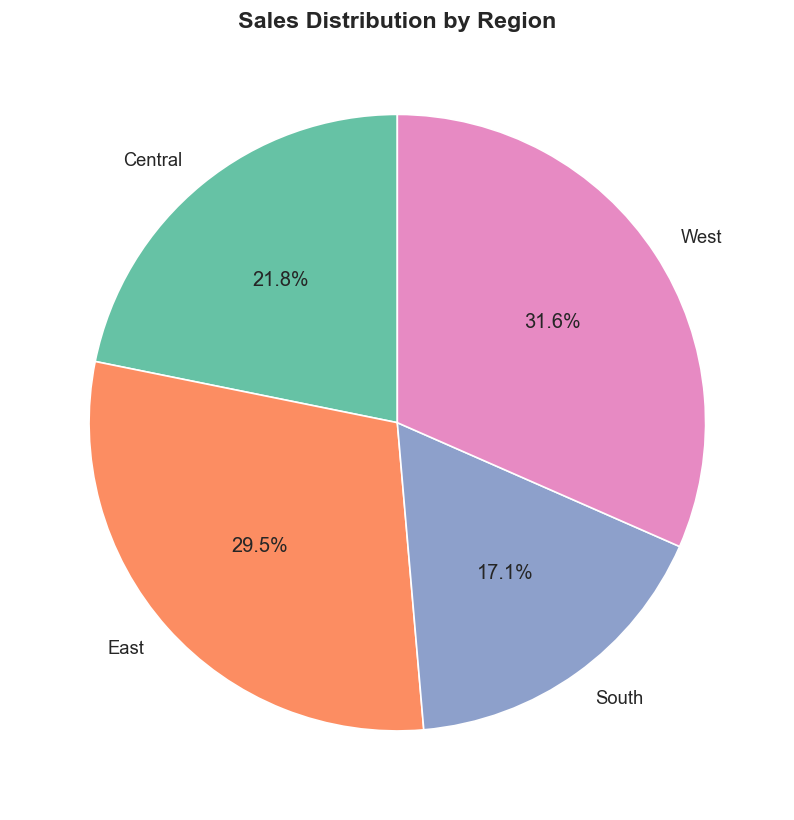

In [7]:
# --- Chart 5: Sales by Region (Pie) ---
fig, ax = plt.subplots(figsize=(7, 7))
region_sales = df.groupby('Region')['Sales'].sum()
ax.pie(region_sales, labels=region_sales.index, autopct='%1.1f%%',
       startangle=90, colors=sns.color_palette("Set2"))
ax.set_title('Sales Distribution by Region', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../exports/05_region_pie.png')
plt.show()

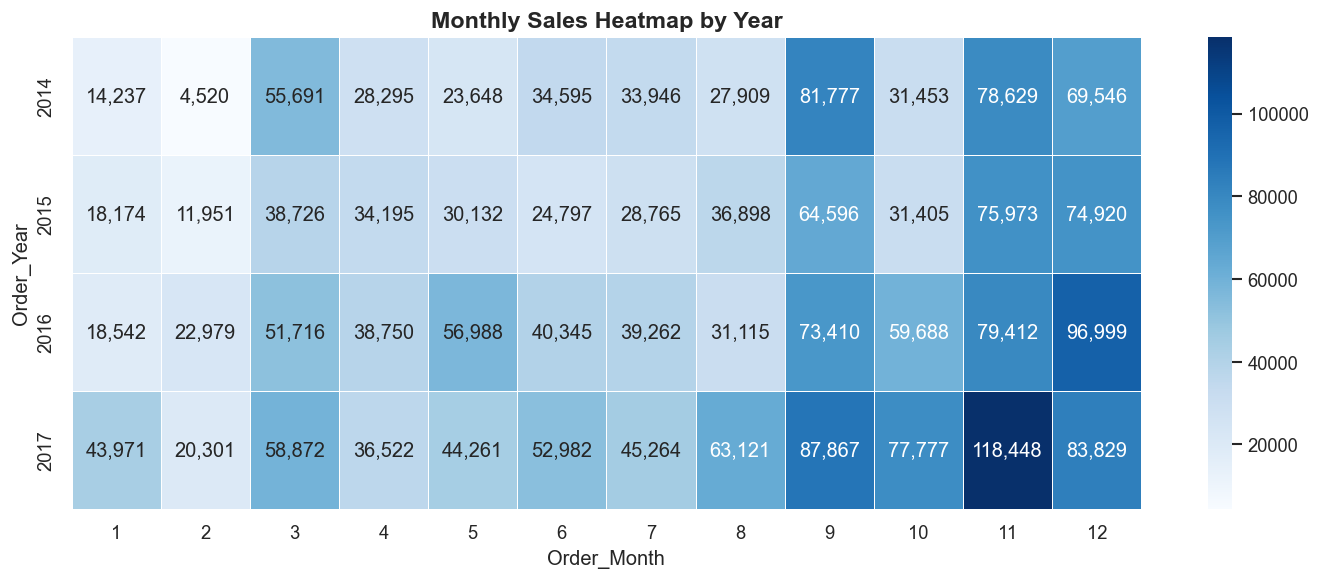

In [8]:
# --- Chart 6: Monthly Sales Heatmap ---
fig, ax = plt.subplots(figsize=(12, 5))
monthly = df.groupby(['Order_Year', 'Order_Month'])['Sales'].sum().unstack()
sns.heatmap(monthly, cmap='Blues', fmt=',.0f', annot=True, linewidths=0.5, ax=ax)
ax.set_title('Monthly Sales Heatmap by Year', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../exports/06_monthly_heatmap.png')
plt.show()

In [9]:
print("✅ All charts saved to exports/")

✅ All charts saved to exports/
